In [2]:
from datasets import load_dataset


c:\Users\Milan\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


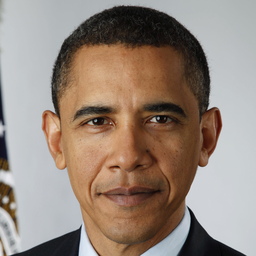

30 30 30


In [8]:
from IPython.display import display

def display_celebrity_image():
    # Load the dataset from Hugging Face
    dataset = load_dataset("guloyy/celebrities_TOY", name="cropped", split="train")
    
    obama_images = []
    taylor_images = []
    yann_images = []
    for row in dataset:
        # Convert label integer to its string name if it's a ClassLabel, or check raw string
        if row["label"] == 0:  
            obama_images.append(row["image"])
        if row["label"] == 1:  
            taylor_images.append(row["image"])
        if row["label"] == 2:  
            yann_images.append(row["image"])
    display(obama_images[0])
    print(len(obama_images), len(taylor_images), len(yann_images))

        
display_celebrity_image()

In [9]:
dataset = load_dataset("guloyy/celebrities_TOY", name="cropped", split="train")
print(len(dataset))

90


In [ ]:

def display_celebrity_image(dataset_name, celebrity_name):
    # Load the dataset from Hugging Face
    # Setting trust_remote_code=True is often required for custom user datasets
    dataset = load_dataset(dataset_name, trust_remote_code=True)
    
    # Check the typical splits (usually 'train' contains the data)
    split_name = 'train' if 'train' in dataset else list(dataset.keys())[0]
    active_dataset = dataset[split_name]
    
    # Find the target column dynamically (usually 'label' or 'name')
    label_column = None
    for col in ['label', 'name', 'identity', 'celebrity']:
        if col in active_dataset.column_names:
            label_column = col
            break
            
    if not label_column:
        raise ValueError(f"Could not identify the text label column. Available columns: {active_dataset.column_names}")
        
    # Find the column containing the image data
    image_column = 'image' if 'image' in active_dataset.column_names else 'image_crop'
    if image_column not in active_dataset.column_names:
        raise ValueError(f"Could not find an image column. Available columns: {active_dataset.column_names}")

    # Search for rows where the label matches or contains the target name
    matched_row = None
    normalized_target = celebrity_name.lower().replace(" ", "_")
    
    for row in active_dataset:
        current_label = str(row[label_column]).lower().replace(" ", "_")
        if normalized_target in current_label:
            matched_row = row
            break
            
    if matched_row:
        # Hugging Face automatically decodes images into PIL Image objects
        pil_image = matched_row[image_column]
        print(f"Displaying image for: {matched_row[label_column]}")
        pil_image.show()
    else:
        print(f"Could not find any images matching '{celebrity_name}' in the dataset.")

# Example usage:
display_celebrity_image("guloyy/celebrities_TOY", "Barack Obama")